### Метод опорних векторів (Support Vector Machine, SVM)

In [1]:
import numpy as np
from sklearn import datasets
from sklearn.svm import SVC
import matplotlib.pyplot as plt

In [2]:
# Load the iris dataset (for simplicity)
# sepal - Чашолисток (2)
# petal - Пелюстка (3)
iris = datasets.load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [3]:
X = iris.data[:, :2]
y = iris.target
X[:10]  # чашолисток: довжина і ширина

array([[5.1, 3.5],
       [4.9, 3. ],
       [4.7, 3.2],
       [4.6, 3.1],
       [5. , 3.6],
       [5.4, 3.9],
       [4.6, 3.4],
       [5. , 3.4],
       [4.4, 2.9],
       [4.9, 3.1]])

In [4]:
y[0:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

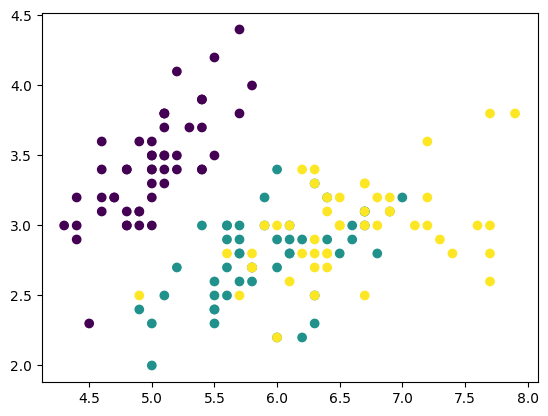

In [5]:
# Plot the data
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')

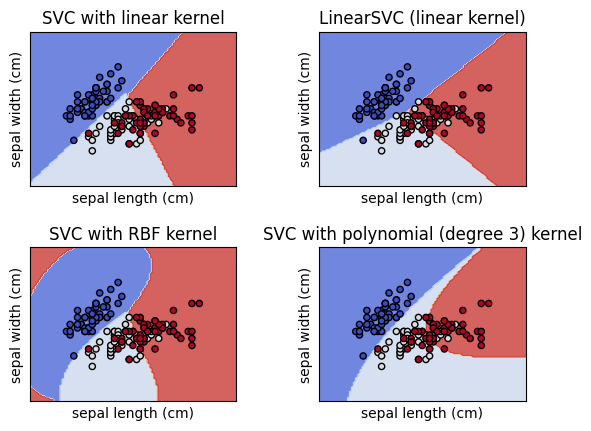

In [6]:
import matplotlib.pyplot as plt

from sklearn import datasets, svm
from sklearn.inspection import DecisionBoundaryDisplay

X = iris.data[:, :2]
y = iris.target

# we create an instance of SVM and fit out data. We do not scale our
# data since we want to plot the support vectors
C = 1.0     # SVM regularization parameter
models = (
    svm.SVC(kernel="linear", C=C),
    svm.LinearSVC(C=C, max_iter=10000, dual="auto"),
    svm.SVC(kernel='rbf', gamma=0.7, C=C),
    svm.SVC(kernel='poly', degree=3, gamma='auto', C=C),
)
models = (clf.fit(X, y) for clf in models)

# title for the plots
titles = (
    'SVC with linear kernel',
    'LinearSVC (linear kernel)',
    'SVC with RBF kernel',
    'SVC with polynomial (degree 3) kernel',
)

# Set-up 2x2 grid for plotting
fig, sub = plt.subplots(2, 2)
plt.subplots_adjust(wspace=0.4, hspace=0.4)

X0, X1 = X[:, 0], X[:, 1]

for clf, title, ax in zip(models, titles, sub.flatten()):
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        response_method='predict',
        cmap=plt.cm.coolwarm,
        alpha=0.8,
        ax=ax,
        xlabel=iris.feature_names[0],
        ylabel=iris.feature_names[1],
    )
    ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)

plt.show()

#### Simple example

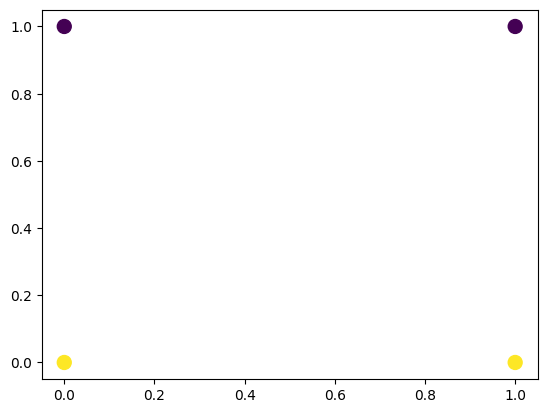

In [7]:
X = np.array([
    [1, 1],
    [0, 0],
    [1, 0],
    [0, 1],
])

y = np.array([0, 1, 1, 0])
plt.scatter(X[:, 0], X[:, 1], c=y, s=100, alpha=1, cmap='viridis')

In [8]:
model = SVC(kernel='linear')
model.fit(X, y)
model.decision_function(X)

array([-1.,  1.,  1., -1.])

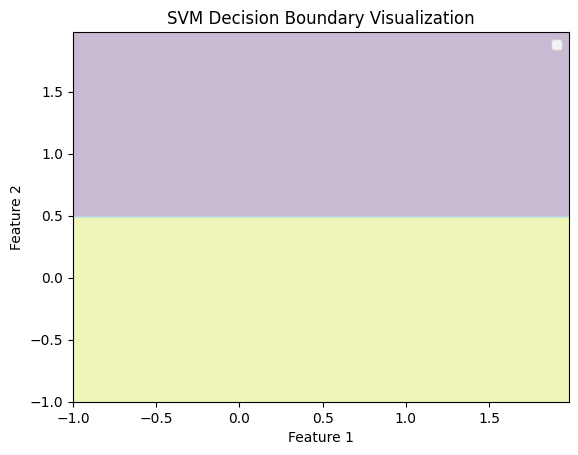

In [9]:
X = np.array([
    [1, 1],
    [0, 0],
    [1, 0],
    [0, 1],
])
y = np.array([0, 1, 1, 0])

# Scatter a meshgrid to generate points for the contour plot
h = .02     # Step size in the mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Train an SVM model
model = SVC(kernel='linear')
model.fit(X, y)

# Obtain decision boundary values for each point in the meshgrid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
# Plot decision boundary as a countour plot
plt.contourf(xx, yy, Z, cmap='viridis', alpha=0.3)

# Set labels and title
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM Decision Boundary Visualization')
plt.legend(labels=['Class 0', 'Class 1'])

# Show the plot
plt.show()

In [10]:
xx

array([[-1.  , -0.98, -0.96, ...,  1.94,  1.96,  1.98],
       [-1.  , -0.98, -0.96, ...,  1.94,  1.96,  1.98],
       [-1.  , -0.98, -0.96, ...,  1.94,  1.96,  1.98],
       ...,
       [-1.  , -0.98, -0.96, ...,  1.94,  1.96,  1.98],
       [-1.  , -0.98, -0.96, ...,  1.94,  1.96,  1.98],
       [-1.  , -0.98, -0.96, ...,  1.94,  1.96,  1.98]], shape=(150, 150))

In [11]:
model.support_      # index of the support vectors

array([0, 3, 1, 2], dtype=int32)

In [12]:
model.__dict__

{'decision_function_shape': 'ovr',
 'break_ties': False,
 'kernel': 'linear',
 'degree': 3,
 'gamma': 'scale',
 'coef0': 0.0,
 'tol': 0.001,
 'C': 1.0,
 'nu': 0.0,
 'epsilon': 0.0,
 'shrinking': True,
 'probability': False,
 'cache_size': 200,
 'class_weight': None,
 'verbose': False,
 'max_iter': -1,
 'random_state': None,
 '_sparse': False,
 'n_features_in_': 2,
 'class_weight_': array([1., 1.]),
 'classes_': array([0, 1]),
 '_gamma': np.float64(2.0),
 'support_': array([0, 3, 1, 2], dtype=int32),
 'support_vectors_': array([[1., 1.],
        [0., 1.],
        [0., 0.],
        [1., 0.]]),
 '_n_support': array([2, 2], dtype=int32),
 'dual_coef_': array([[-1., -1.,  1.,  1.]]),
 'intercept_': array([1.]),
 '_probA': array([], dtype=float64),
 '_probB': array([], dtype=float64),
 'fit_status_': 0,
 '_num_iter': array([2], dtype=int32),
 'shape_fit_': (4, 2),
 '_intercept_': array([-1.]),
 '_dual_coef_': array([[ 1.,  1., -1., -1.]]),
 'n_iter_': array([2], dtype=int32)}

In [13]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X)
accuracy_score(y_pred, y)

1.0

#### With more data

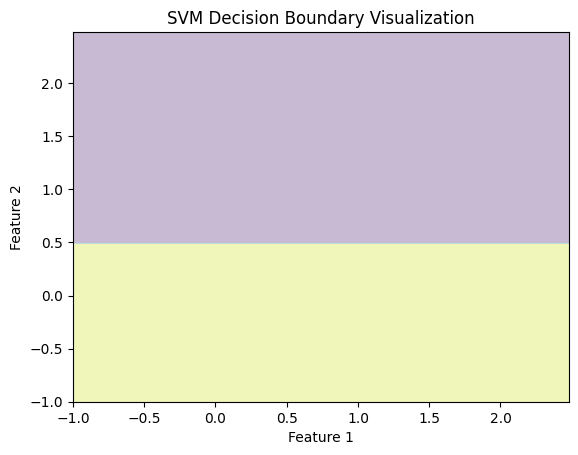

In [16]:
X = np.array([
    [1, 1],
    [0, 0],
    [1, 0],
    [0, 1],
    [1.5, 0],
    [0, 1.5],
])
y = np.array([0, 1, 1, 0, 1, 0])
# Scatter a meshgrid to generate points for the countour plot
h = .02     # Step size in the mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Train an SVM model
model = SVC(kernel='linear')
model.fit(X, y)

# Obtain decision boundary values for each point inthe meshgrid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
# Plot decision boundary as a countour plot
plt.contourf(xx, yy, Z, cmap='viridis', alpha=0.3)

# Set labels and title
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM Decision Boundary Visualization')

# Show the plot
plt.show()

In [15]:
model.support_

array([0, 3, 1, 2], dtype=int32)

In [17]:
model.support_vectors_

array([[1., 1.],
       [0., 1.],
       [0., 0.],
       [1., 0.]])

In [18]:
y_pred = model.predict(X)
accuracy_score(y_pred, y)

1.0

#### Iris (Linear)

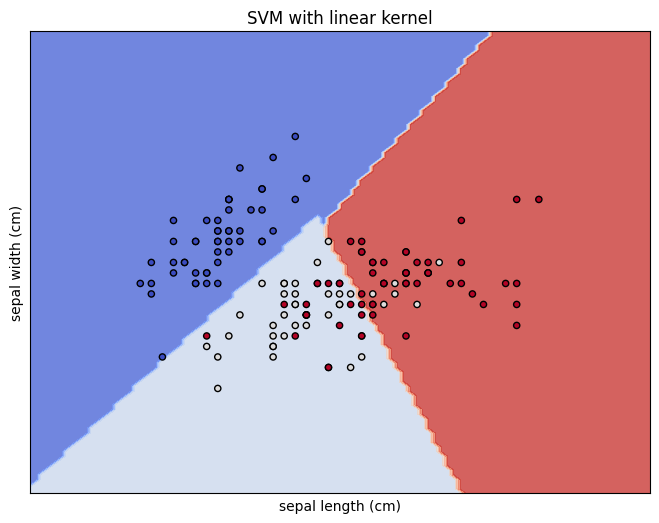

In [20]:
from sklearn import datasets, svm
from sklearn.inspection import DecisionBoundaryDisplay

X = iris.data[:, :2]
y = iris.target

# we create an instance of SVM and fit out data. We do not scale our
# data since we want to plot the support vectors
C = 1.0     # SVM regulization parameter
model = svm.SVC(kernel='linear', C=C)
model.fit(X, y)

# title for the plots
title = 'SVM with linear kernel'

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot()

X0, X1 = X[:, 0], X[:, 1]

disp = DecisionBoundaryDisplay.from_estimator(
    model,
    X,
    response_method='predict',
    cmap=plt.cm.coolwarm,
    alpha=0.8,
    ax=ax,
    xlabel=iris.feature_names[0],
    ylabel=iris.feature_names[1],
)

ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
ax.set_xticks(())
ax.set_yticks(())
ax.set_title(title)

plt.show()

In [21]:
y_pred = model.predict(X)
accuracy_score(y_pred, y)

0.82

#### Kernel Trick

In [22]:
# Radial Basis Function (RBF) kernel calculation
def rbf_kernel(X1, X2, gamma=1.0):
    dist_squared = np.sum((X1[:, np.newaxis] - X2) ** 2, axis=-1)
    return np.exp(-gamma * dist_squared)

# Calculate RBF kernel values
gamma = (1/(X.shape[1] * X.var()))
rbf_kernel_values = rbf_kernel(X, X, gamma=gamma)
rbf_kernel_values   # pairwise!



array([[1.        , 0.94078259, 0.94873719, ..., 0.62801492, 0.77352099,
        0.82916218],
       [0.94078259, 1.        , 0.98330149, ..., 0.58341051, 0.67745403,
        0.81018406],
       [0.94873719, 0.98330149, 1.        , ..., 0.50136557, 0.617528  ,
        0.73232501],
       ...,
       [0.62801492, 0.58341051, 0.50136557, ..., 1.        , 0.94873719,
        0.92702219],
       [0.77352099, 0.67745403, 0.617528  , ..., 0.94873719, 1.        ,
        0.94873719],
       [0.82916218, 0.81018406, 0.73232501, ..., 0.92702219, 0.94873719,
        1.        ]], shape=(150, 150))